# Mech Interp on DEQNs: Brock-Mirman Walkthrough

A six-chapter narrated example. We train tiny `LinearPlusMLP` networks on
Brock-Mirman at three risk-aversion settings, then peel them open chapter
by chapter.

Each chapter introduces one mech-interp move on a substrate where every
claim is checkable against a known economic solution.

**Outline:**
- Ch 0 — Setup: train the networks, see what they compute
- Ch 1 — Output decomposition (BK linearization vs MLP correction)
- Ch 2 — Per-neuron contributions inside the MLP correction
- Ch 3 — Linear probes: what do live neurons encode?
- Ch 4 — Ablation: causation vs correlation
- Ch 5 — The intensity dial: γ ∈ {1, 2, 5}
- Ch 6 — Honest limits and pointers forward

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import NetworkConfig, OptimizerConfig, TrainConfig
from deqn_jax.interp import (
    ablate_neuron,
    branch_decompose,
    forward_with_activations,
    linear_probe,
    neuron_contributions,
)
from deqn_jax.training.trainer import train_from_config

FIGDIR = "../docs/dev/figures/interp"
GAMMAS = (1.0, 2.0, 5.0)
HIDDEN = (16, 16)
SEED = 0
EPISODES = 200

## Chapter 0 — Setup

We train three Brock-Mirman policies, one per γ. Each is a
`LinearPlusMLP` with hidden sizes `(16, 16)` and the same seed. The linear
branch is the Blanchard-Kahn first-order solution of the model (fixed,
not trained). The MLP branch is initialized so that the network *is* the
BK linearization at init; training carves the nonlinear correction.

Below we train all three networks, then plot the γ=2 learned policy on a
(k, z) grid. Chapters 1–4 focus on the γ=2 network; γ=1 and γ=5 come back
in Chapter 5.

In [2]:
def train_one(gamma: float):
    cfg = TrainConfig(
        model="brock_mirman",
        constants={"gamma": gamma},
        episodes=EPISODES,
        episode_length=128,
        batch_size=64,
        mc_samples=8,
        seed=SEED,
        network=NetworkConfig(
            type="linear_plus_mlp",
            hidden_sizes=HIDDEN,
            activation="tanh",
        ),
        optimizer=OptimizerConfig(name="adam", learning_rate=1e-3),
    )
    trained, history = train_from_config(cfg)
    final_loss = history["loss"][-1] if "loss" in history else float("nan")
    print(f"γ={gamma}  final loss={final_loss:.3e}")
    return trained


nets = {g: train_one(g) for g in GAMMAS}
net = nets[2.0]  # primary network for Ch 1–4

  Constants override: {'gamma': 1.0}


DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=1.72e-08 | grad=6.51e-05 | 19 ep/s
    euler=1.72e-08


  [200/200] loss=4.12e-09 | grad=2.64e-05 | 21 ep/s
    euler=4.12e-09
Training complete in 9.5s (21 ep/s)
Final loss: 4.12e-09
  euler: 4.12e-09
γ=1.0  final loss=4.118e-09
  Constants override: {'gamma': 2.0}
DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=6.18e-08 | grad=1.19e-04 | 21 ep/s
    euler=6.18e-08


  [200/200] loss=4.48e-08 | grad=7.76e-05 | 22 ep/s
    euler=4.48e-08
Training complete in 9.1s (22 ep/s)
Final loss: 4.48e-08
  euler: 4.48e-08
γ=2.0  final loss=4.485e-08
  Constants override: {'gamma': 5.0}
DEQN-JAX Training
  Model:           brock_mirman
  Optimizer:       adam (lr=1e-03)
  Precision:       float32
  Network:         LINEAR_PLUS_MLP 2 → 16 → 16 → 1 (H=1)
  Parameters:      342
  Batch size:      64
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (128×64=8192 states) → 1 epoch(s) × 128 minibatch(es) of 64 = 128 grad updates/cycle (25600 total over 200 cycles)


  [100/200] loss=7.91e-07 | grad=5.56e-04 | 21 ep/s
    euler=7.91e-07


  [200/200] loss=7.46e-07 | grad=5.43e-04 | 22 ep/s
    euler=7.46e-07
Training complete in 9.0s (22 ep/s)
Final loss: 7.46e-07
  euler: 7.46e-07
γ=5.0  final loss=7.456e-07


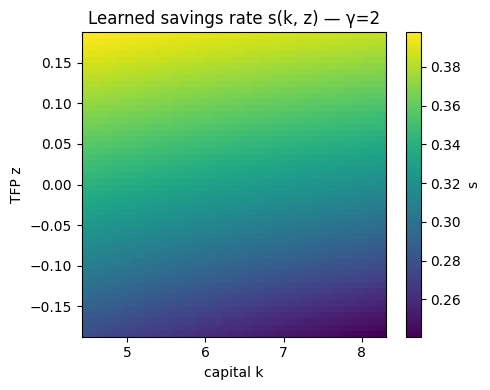

In [3]:
def state_grid(net, n=50):
    """Grid over ±2σ of the ergodic support around the network's SS."""
    k_ss = float(net.ss_state[0])
    z_ss = float(net.ss_state[1])
    sigma_z = 0.04
    rho = 0.9
    z_std = sigma_z / np.sqrt(1.0 - rho**2)
    ks = np.linspace(0.7 * k_ss, 1.3 * k_ss, n)
    zs = np.linspace(z_ss - 2 * z_std, z_ss + 2 * z_std, n)
    K, Z = np.meshgrid(ks, zs)
    states = jnp.stack([K.ravel(), Z.ravel()], axis=-1)
    return states, K, Z


states, K, Z = state_grid(net)
policy = np.asarray(net(states)).reshape(K.shape)

fig, ax = plt.subplots(figsize=(5, 4))
pcm = ax.pcolormesh(K, Z, policy, shading="auto", cmap="viridis")
ax.set_xlabel("capital k")
ax.set_ylabel("TFP z")
ax.set_title("Learned savings rate s(k, z) — γ=2")
fig.colorbar(pcm, ax=ax, label="s")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/ch0_policy_gamma2.png", dpi=150)
plt.show()